# LLMs para classificação de Textos

## 0. Setup

In [17]:
import os
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from groq import Groq
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from google import genai

In [18]:
%env GROQ_API_KEY=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

env: GROQ_API_KEY=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


In [19]:
SEED = 2026

LABELS = [
    "Anthropic",
    "Google",
    "Human",
    "Meta",
    "OpenAI"
]

MODEL = "llama-3.1-8b-instant"
GROQ_API_KEY=os.getenv("GROQ_API_KEY")

groq_client = Groq(api_key=GROQ_API_KEY)

## 1. Carregamento e Pré-processamento dos Dados

In [20]:
df_train = pd.read_csv("data/train.csv", sep=";")
df_test  = pd.read_csv("data/test.csv", sep=";")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()

df_train["clean_text"] = df_train["Text"].apply(clean_text)
df_test["clean_text"] = df_test["Text"].apply(clean_text)


In [21]:
gold_test = df_test["Label"].tolist()

In [22]:
len(df_train)

26500

In [23]:
len(df_test)

314

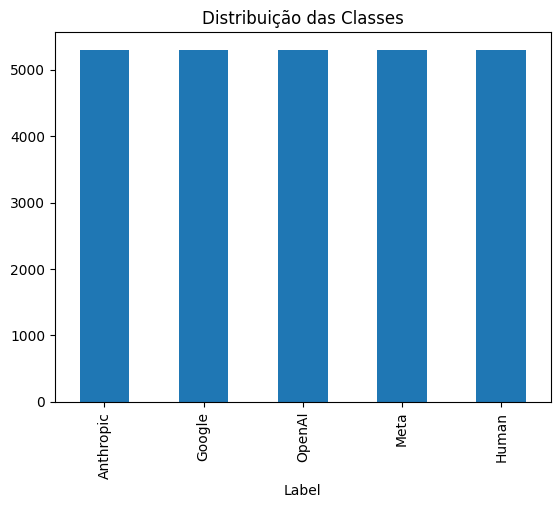

In [24]:
df_train["Label"].value_counts().plot(kind="bar", title="Distribuição das Classes")
plt.show()

## 2. Definição de prompt

In [25]:
def build_zero_shot_prompt(example):
    prompt = f"""
You are a strict classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Return ONLY one label.

Text:\n
{example["clean_text"]}
"""
    return prompt.strip()

In [26]:
support_examples = df_train.sample(n=5, random_state=SEED).to_dict(orient="records")

def format_example(ex):
    return f"""
Text: "{ex["clean_text"]}"
Label: {ex["Label"]}
"""

def build_few_shot_prompt(example, support_examples):
    support_block = ""

    for support_example in support_examples:
        support_block += format_example(support_example)
    
    prompt = f"""
You are a text classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Examples:
{support_block}

Now classify:

Text:
{example["clean_text"]}

Return ONE and ONLY label.
"""
    return prompt.strip()

## 3. API helpers

In [27]:
def ask_groq(prompt, model=MODEL):
    response = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    print(response)

    return response.choices[0].message.content

In [28]:
VALID_LABELS = set(LABELS)

def normalize_prediction(text):
    if text is None:
        return None

    text = text.strip()

    if text in VALID_LABELS:
        return text

    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label
            
    return None

In [29]:
def evaluate_predictions(predictions, gold_labels):
    rows = []
    for gold_label, prediction in zip(gold_labels, predictions):
        rows.append({
            "gold_label": gold_label,
            "prediction": prediction,
            "correct":    prediction == gold_label,
        })
    return pd.DataFrame(rows)

In [30]:
def accuracy(preds, gold_labels):
    if not gold_labels:
        return 0.0
    return sum(p == g for p, g in zip(preds, gold_labels)) / len(gold_labels)


## 4. Zero-shot

In [31]:
def run_experiment(
    dataset_split,
    ask_fn,
    model_name,
    prompt_builder,
    support_examples=None,
    sleep_seconds=0.8,
):

    predictions, raw_outputs = [], []

    for example in dataset_split:
        try:
            prompt = (
                prompt_builder(example, support_examples)
                if support_examples
                else prompt_builder(example)
            )
            raw  = ask_fn(prompt, model=model_name)
            pred = normalize_prediction(raw)
            raw_outputs.append(raw)
            predictions.append(pred)
        except Exception as e:
            print(f"Error: {e}")
            raw_outputs.append(None)
            predictions.append(None)

        time.sleep(sleep_seconds)

    return predictions, raw_outputs

In [32]:
zs_preds, _ = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=MODEL,
    prompt_builder=build_zero_shot_prompt,
)

ChatCompletion(id='chatcmpl-600ce690-3fd5-4aca-ae88-ec3e71d86442', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774980576, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_4387d3edbb', usage=CompletionUsage(completion_tokens=3, prompt_tokens=182, total_tokens=185, completion_time=0.008437058, completion_tokens_details=None, prompt_time=0.012210986, prompt_tokens_details=None, queue_time=0.087320719, total_time=0.020648044), usage_breakdown=None, x_groq=XGroq(id='req_01kn2hcdbgfvf8rapry7a86fc6', debug=None, seed=595815199, usage=None))
ChatCompletion(id='chatcmpl-9954dfda-ccc8-400c-a390-621bbbf80e3c', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', a

In [33]:
accuracy(zs_preds, gold_test)

0.24203821656050956

In [34]:
eval = evaluate_predictions(zs_preds, gold_test)

print("=== Zero-Shot ===")
display(eval)

=== Zero-Shot ===


,gold_label,prediction,correct
0,Human,OpenAI,False
1,Meta,Human,False
2,Google,Human,False
3,Meta,Anthropic,False
4,Human,Human,True
...,...,...,...
309,Human,Meta,False
310,OpenAI,OpenAI,True
311,Google,Meta,False
312,Human,Anthropic,False


## 5a. Static Few-Shot

In [35]:
support_examples = []
seen = set()
complete = False

for _, row in df_train.iterrows():
    label = row["Label"]
    
    if label not in seen:
        support_examples.append(row.to_dict())
        seen.add(label)

    
    if len(seen) == len(LABELS):
        break


for ex in support_examples:
    print(ex["Label"])
    print(format_example(ex))
    print("-" * 80)    

Anthropic

Text: "the human heart beats approximately         times per day"
Label: Anthropic

--------------------------------------------------------------------------------
Google

Text: "the human brain is a complex organ  consuming approximately     of the body s total oxygen and calories"
Label: Google

--------------------------------------------------------------------------------
OpenAI

Text: "water is a polar molecule  resulting in unique properties like high surface tension and the ability to dissolve many substances"
Label: OpenAI

--------------------------------------------------------------------------------
Meta

Text: "the human nose can detect over   trillion different scents due to hundreds of different types of olfactory receptors"
Label: Meta

--------------------------------------------------------------------------------
Human

Text: "the cell is the basic structural and functional unit of all forms of life or organisms"
Label: Human

---------------------------

In [36]:
fs_preds, _ = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=MODEL,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

ChatCompletion(id='chatcmpl-938b0333-a155-41fd-93fe-37d40e1a3948', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774981465, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_8639719ff2', usage=CompletionUsage(completion_tokens=2, prompt_tokens=317, total_tokens=319, completion_time=0.009298247, completion_tokens_details=None, prompt_time=0.028370183, prompt_tokens_details=None, queue_time=0.018893607, total_time=0.03766843), usage_breakdown=None, x_groq=XGroq(id='req_01kn2j7gykf74arvqgvc5d4tn9', debug=None, seed=325241297, usage=None))
ChatCompletion(id='chatcmpl-4fec98c2-ea3a-4d90-8466-6799bfee2396', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', ann

In [37]:
accuracy(fs_preds, gold_test)

0.3471337579617834

## 5b. RAG Few-shot

Utiliza RAG para "buscar" um exemplo mais próximo de cada classe.

In [38]:
tfidf_vectorizer = TfidfVectorizer()
train_texts_list  = df_train["clean_text"].tolist()
train_tfidf       = tfidf_vectorizer.fit_transform(train_texts_list)
train_records_rag = df_train.to_dict(orient="records")

print(
    f"TF-IDF index ready: {len(train_texts_list)} training examples, "
    f"{train_tfidf.shape[1]} features"
)

TF-IDF index ready: 26500 training examples, 21098 features


In [39]:
def select_rag_support_examples(
    query_text, train_records, train_tfidf, vectorizer, labels=LABELS
):
    query_vec = vectorizer.transform([query_text])
    sims = cosine_similarity(query_vec, train_tfidf).flatten()

    rag_support = []
    for label in labels:
        class_indices = [
            i for i, r in enumerate(train_records) if r["Label"] == label
        ]
        if not class_indices:
            continue
        best_idx = int(np.argmax([sims[i] for i in class_indices]))
        rag_support.append(train_records[class_indices[best_idx]])
    return rag_support

In [40]:
def run_experiment_rag(
    dataset_split,
    ask_fn,
    model_name,
    prompt_builder,
    train_records,
    train_tfidf,
    vectorizer,
    labels=LABELS,
    sleep_seconds=0.8,
):

    predictions, raw_outputs = [], []
    for example in dataset_split:
        try:
            support_examples = select_rag_support_examples(
                example["clean_text"],
                train_records,
                train_tfidf,
                vectorizer,
                labels,
            )
            prompt = prompt_builder(example, support_examples)
            raw   = ask_fn(prompt, model=model_name)
            pred  = normalize_prediction(raw)
            raw_outputs.append(raw)
            predictions.append(pred)
        except Exception as e:
            print(f"Error: {e}")
            raw_outputs.append(None)
            predictions.append(None)
        time.sleep(sleep_seconds)
    return predictions, raw_outputs

In [41]:
rag_preds, _ = run_experiment_rag(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=MODEL,
    prompt_builder=build_few_shot_prompt,
    train_records=train_records_rag,
    train_tfidf=train_tfidf,
    vectorizer=tfidf_vectorizer,
    sleep_seconds=1.5
)

ChatCompletion(id='chatcmpl-4d634298-0ccc-4a95-b268-a447f0cfcca9', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774982462, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_6a1eabf260', usage=CompletionUsage(completion_tokens=2, prompt_tokens=675, total_tokens=677, completion_time=0.007660253, completion_tokens_details=None, prompt_time=0.037798547, prompt_tokens_details=None, queue_time=0.018043881, total_time=0.0454588), usage_breakdown=None, x_groq=XGroq(id='req_01kn2k5z97ez4rv8rmkwh5hcdt', debug=None, seed=1259189246, usage=None))
ChatCompletion(id='chatcmpl-f83a809b-d310-4861-8140-98a467a76a0d', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', ann

In [42]:
accuracy(rag_preds, gold_test)

0.27070063694267515

In [43]:
df_rag = evaluate_predictions(rag_preds,    gold_test)


print("=== RAG Few-shot — Groq ===")
display(df_rag)


=== RAG Few-shot — Groq ===


,gold_label,prediction,correct
0,Human,Human,True
1,Meta,Human,False
2,Google,OpenAI,False
3,Meta,OpenAI,False
4,Human,Human,True
...,...,...,...
309,Human,OpenAI,False
310,OpenAI,OpenAI,True
311,Google,OpenAI,False
312,Human,Human,True


## 6. Resultados

,Setting,Accuracy
0,zero-shot,0.242038
1,few-shot (static),0.347134
2,few-shot (RAG),0.270701


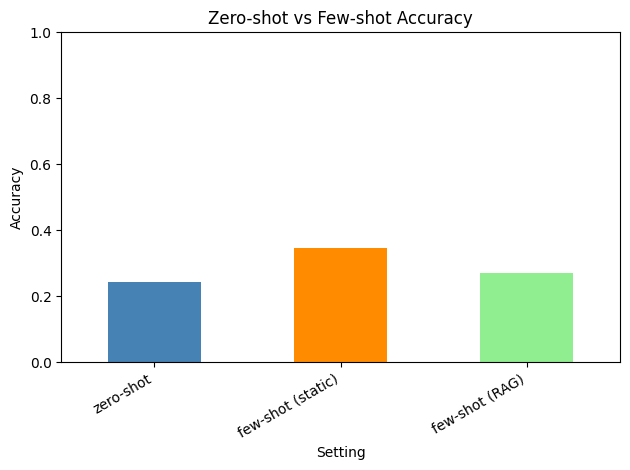

In [44]:
results = {

    "zero-shot":          accuracy(zs_preds,    gold_test),
    "few-shot (static)":  accuracy(fs_preds,    gold_test),
    "few-shot (RAG)":     accuracy(rag_preds,   gold_test),
}

rag_df = pd.DataFrame(
    list(results.items()), columns=["Setting", "Accuracy"]
)

display(rag_df)

colors = ["steelblue", "darkorange", "lightgreen"] * 4
rag_df.set_index("Setting")["Accuracy"].plot(
    kind="bar",
    title="Zero-shot vs Few-shot Accuracy",
    ylim=(0, 1),
    color=colors,
)
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()